## Paper

In [1]:
import copy
import importlib
import os
from pathlib import Path
import random
import warnings

from matplotlib import pyplot as plt
from matplotlib import patches as mpl_patches
from matplotlib import font_manager as fm
import numpy as np
import ratinabox
from ratinabox import utils as rutils
import scipy.stats
from tqdm import tqdm

from predhpc import agent, env, plot_fcts, run_manager
from predhpc.experiments import metrics, linear_track
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, hyper_util, plot_util, params_util, animate_util, gen_util, learn_util, signal_util

%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

### Helper functions

In [4]:
def seed_all(seed=None):
    random.seed(seed)
    np.random.seed(seed)

def delete_np_dict(filepath):
    filepath = Path(filepath)
    if filepath.is_file():
        print(f"Deleting {filepath}.")
        filepath.unlink()

def load_np_dict(filepath):
    filepath = Path(filepath)
    data_dict = None
    if filepath.is_file():
        print(f"Loading data from {filepath}.")
        data_dict = np.load(filepath)
    return data_dict

def save_np_dict(filepath, data_dict):
    filepath = Path(filepath)
    if filepath.is_file():
        print(f"Overwriting {filepath}.")
    else:
        print(f"Saving data to {filepath}.")
    
    np.savez(filepath, **data_dict)

In [5]:
def set_plot_font():
    gen_dir = Path(os.environ["HOME"], "Documents")
    font_dir = None
    for sub_dir in [Path("fonts"), Path("tools", "fonts")]:
        if Path(gen_dir, sub_dir).is_dir():
            font_dir = Path(gen_dir, sub_dir)
    if font_dir is None:
        print("Font directory not found.")
    else:
        font_files = fm.findSystemFonts(fontpaths=str(font_dir))
        for font_file in font_files:
            fm.fontManager.addfont(font_file)
        plt.rcParams["font.family"] = "Arial"

def set_plot_format():
    plot_util.stylize_plots_for_notebook()
    fs = 12
    lw = 1.7
    tick_len = 6
    rcParams = {
        "axes.titlesize"   : fs,
        "axes.labelsize"   : fs,
        "axes.linewidth"   : lw,
        "xtick.labelsize"  : fs - 1,
        "xtick.major.size" : tick_len,
        "xtick.major.width": lw,
        "ytick.labelsize"  : fs - 1,
        "ytick.major.size" : tick_len,
        "ytick.major.width": lw,
    }
    plt.rcParams.update(rcParams)
    set_plot_font()

## Linear analysis functions

In [6]:
def get_linear_Pyrs(
    speed_mean=params_util.SPEED_MEAN_LINEAR, 
    speed_std=params_util.SPEED_STD, 
    wait_at_end=int(15 / params_util.DT),
    log_BTSP=True
):

    target_position = params_util.get_target_position()
    
    agent_params = params_util.get_agent_params(
        environment="linear",
        target_position=target_position,
        speed_mean=speed_mean,
        speed_std=speed_std,
        wait_at_end=wait_at_end,
    )
    
    Pyr_params = params_util.get_Pyr_params(
        environment="linear",
        log_BTSP=log_BTSP,
    )
    
    Pyrs = run_manager.init_env_objects(
        agent_params=agent_params,
        Pyr_params=Pyr_params,
        environment="linear",
        plot=False,
        )

    return Pyrs

def run_linear(Pyrs=None, max_num_steps=3800, max_time_min=None, **kwargs):
    if Pyrs is None:
        Pyrs = get_linear_Pyrs()

    if max_time_min is not None:
        max_num_steps = int(max_time_min * 60 / Pyrs.Agent.dt)
        
    learner = run_manager.learn_1D_BTSP(
        Pyrs,
        BTSP_on=0,
        max_num_steps=max_num_steps,
        plot=False,
        **kwargs
    )

    return learner

def get_rounded_linspace(start, end, n, round=9):
    speed_means = np.linspace(start, end, n)
    if round is not None:
        speed_means = np.around(speed_means, round)
    return speed_means

def run_linear_speeds():
    speed_data = {
        "speed_means": get_rounded_linspace(0.05, 0.4, 29),
        "PF_widths": list(),
        "PF_weights": list(),
    }
    for speed_mean in tqdm(speed_data["speed_means"]):
        seed_all(SEED)
        Pyrs = get_linear_Pyrs(speed_mean=speed_mean, speed_std=0, log_BTSP=False, wait_at_end=0)
        learner = run_linear(Pyrs, max_time_min=1.2, no_logs=True)
        speed_data["PF_widths"].append(metrics.compute_PC_FWHM(Pyrs))
        speed_data["PF_weights"].append(learner.get_recorded_weights()["weights"][:, 0])
    
    speed_data = {key: np.asarray(val) for key, val in speed_data.items()}

    return speed_data

def run_linear_shifts():
    seed_all(SEED)
    
    shift_data = {
        "target_shifts": get_rounded_linspace(-3.6, 2.4, 61),
        "PF_widths": list(),
        "PF_weights": list(),
    }
    
    Pyrs = get_linear_Pyrs(speed_std=0, log_BTSP=False, wait_at_end=0)
    orig_learner = run_linear(Pyrs, max_time_min=1.2, no_logs=True)
    for shift in tqdm(shift_data["target_shifts"]):
        seed_all(SEED)
        learner = copy.deepcopy(orig_learner)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, message="Target position")
            learner.Pyrs.Agent.move_target_position(shift)
        learner = run_linear(learner, max_time_min=1.2, no_logs=True)
        shift_data["PF_widths"].append(metrics.compute_PC_FWHM(Pyrs))
        shift_data["PF_weights"].append(learner.get_recorded_weights()["weights"][:, 0])

    num = max([len(wei) for wei in shift_data["PF_weights"]])
    shift_data["PF_weights"] = [
        np.pad(wei, ((0, num - len(wei)), (0, 0)), "constant", constant_values=np.nan) 
        for wei in shift_data["PF_weights"]
    ]
    shift_data = {key: np.asarray(val) for key, val in shift_data.items()}
    
    return shift_data

def run_fct(fct_name="linear_speeds", overwrite=False):

    if fct_name == "linear_speeds":
        fct = run_linear_speeds
        data_name = "speed_data"
    elif fct_name == "linear_shifts":
        fct = run_linear_shifts
        data_name = "shift_data"
    else:
        raise ValueError(f"fct_name '{fct_name}' not recognized.")

    save_path = Path(ratinabox.figure_directory, f"{data_name}_{SEED}.npz")
    if overwrite:
        delete_np_dict(save_path)
    data_dict = load_np_dict(save_path)

    if data_dict is None:
        print("Running...")
        data_dict = fct()
        save_np_dict(save_path, data_dict)

    return data_dict

### Plot functions

In [7]:
def format_PF_xaxis(sub_ax):
    sub_ax.set_xlim([0, 6])
    sub_ax.set_xticks([0, 6])
    plot_util.expand_ticks(sub_ax, axis="x", num_ticks=7, alternating=True, round_dec=0)

def plot_weights(PCs, weights, shift=0, scale=4, alpha=0.8, lw=1, relative=None, sub_ax=None):
    if sub_ax is None:
        _, sub_ax = plt.subplots(figsize=(5, 4))
    PC_centers = PCs.place_cell_centres[:, 0]
    plot_weights = weights * scale + shift
    if relative is not None:
        base = relative * scale + shift
        diff = plot_weights - base
        for i, color in enumerate([PCs.color, "royalblue"]):
            diff = -diff if i == 1 else diff
            cond = plot_util.get_greater_condition_for_fill_between(diff)         
            sub_ax.fill_between(PC_centers, base, plot_weights, color=color, alpha=0.3, lw=0, where=cond)
    sub_ax.plot(PC_centers, plot_weights, color=PCs.color, alpha=alpha, lw=lw)
    return sub_ax

### Hyperparameters

In [8]:
SEED = 18
ALL_FIGURES = dict()
set_plot_format()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "paper"))

### Fig. 1: Background

In [9]:
seed_all(SEED)
Pyrs = get_linear_Pyrs()
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)

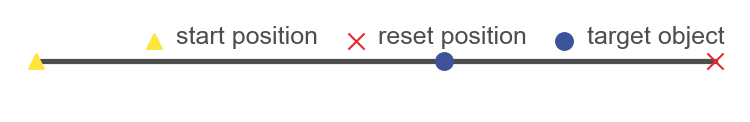

In [10]:
# Panel B
_, sub_ax = plt.subplots(figsize=(6.2, 0.8))
sub_ax = plot_fcts.plot_1D_reset_environment(Ag, minimalist=True, title="", base_s=50, sub_ax=sub_ax)
sub_ax.spines["bottom"].set_linewidth(2.5)
leg = sub_ax.get_legend()
for text in leg.get_texts():
    text_str = text.get_text()
    add_str = "object" if text_str == "target" else "position"
    text.set_text(f"{text_str} {add_str}") 
    text.set_fontsize(12)

ALL_FIGURES["1B"] = sub_ax

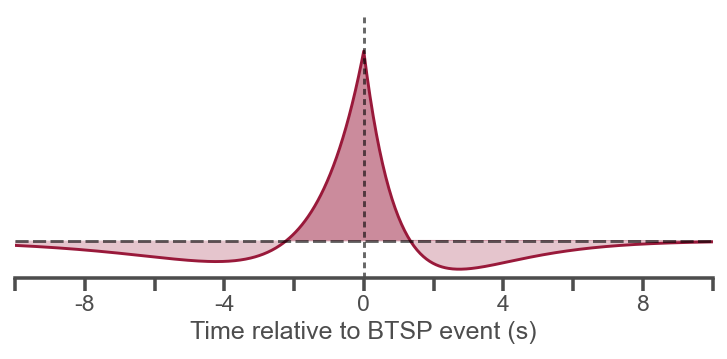

In [11]:
# Panel D
_, sub_ax = plt.subplots(figsize=(6, 2.28))
BTSP_param_dict = params_util.get_default_BTSP_filter_param_dict(incl_BTSP_str=False)
xlims = [-10, 10]

sub_ax = plot_util.plot_summed_exp_kernel(
    dt=Ag.dt, color=PCs.color, xlims=xlims, minimalist=True, lw=1.4, sub_ax=sub_ax, **BTSP_param_dict
)[0]

xticks = np.arange(xlims[0], xlims[1] + 2, 2)
plot_util.set_alternating_ticks(sub_ax, xticks, round_dec=0)
plot_util.pad_axis(sub_ax, axis="y", pad_prop=0.15, prop_high=0.9)
sub_ax.set_xlabel("Time relative to BTSP event (s)")

ALL_FIGURES["1D"] = sub_ax

### Fig. 2: Linear track

In [12]:
seed_all(SEED)
Pyrs = get_linear_Pyrs()
learner = run_linear(Pyrs, max_time_min=1.6)

 18%|███████                                | 580/3200 [00:00<00:04, 637.65it/s]

BTSP event recorded at step 513 (15.39 sec).


 40%|███████████████▎                      | 1293/3200 [00:02<00:03, 632.81it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 3200/3200 [00:05<00:00, 623.73it/s]


Finishing last trajectory.


213it [00:00, 632.25it/s]

Only reached target 3 times (target: 10).
Trajectory lengths (4) to date: 25.60 +/- 16.00 sec each
Trajectory lengths (4) to date: 853.50 +/- 533.36 steps each
1 BTSP event triggered (allowed from steps 0 to 3413): occurred at step 513.


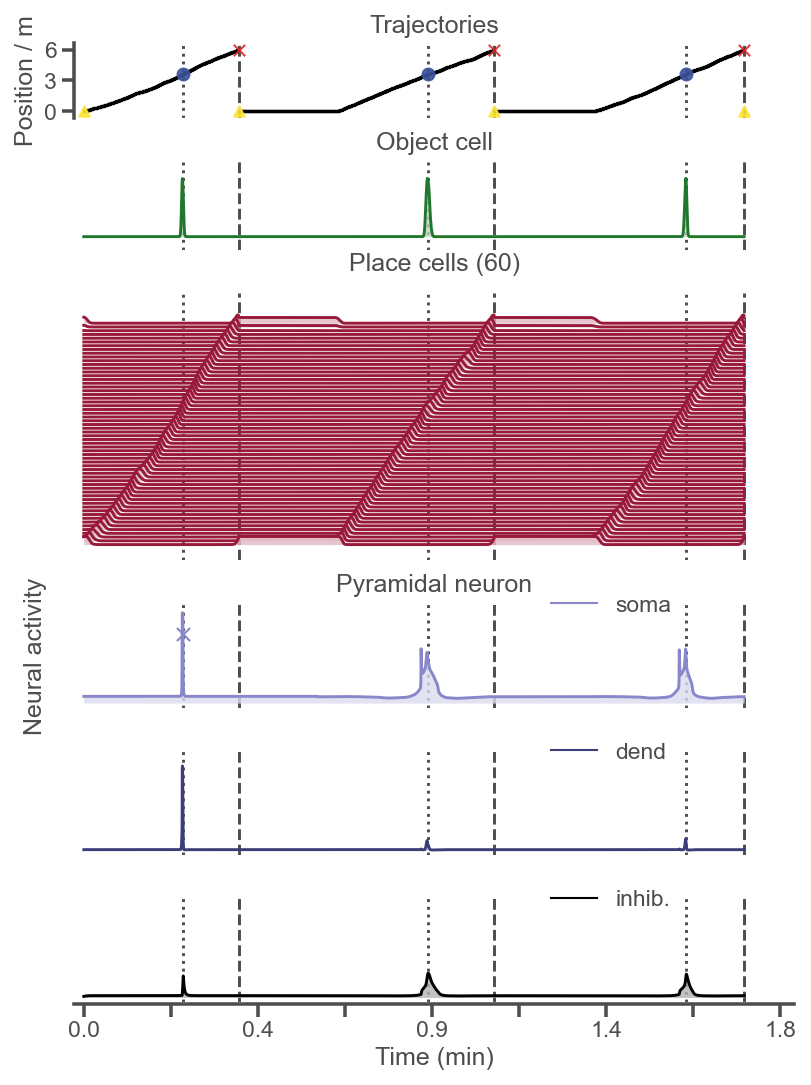

In [13]:
plot_kwargs = {
    "hspace": 0.35, 
    "height_ratios": [0.1, 0.12, 0.36, 0.14, 0.14, 0.14],
    "figsize": (6.2, 8.3),
    "lw": 1.4,
    "s": 1.2,
    "base_s": 25,
}

Pyr_kwargs = {"norm_by": "shared_max", "BTSP_s": 40, "separate_axes": True, "no_legend": True}

axes = plot_fcts.plot_1D_time_info(learner.Pyrs, Pyrs_spikes=False, Pyr_kwargs=Pyr_kwargs, **plot_kwargs)
axes[0, 0].set_yticks([0, 3, 6])
plot_util.expand_ticks(axes[-1, 0], axis="x", num_ticks=9, alternating=True, round_dec=1)
plot_util.pad_axis(axes[0, 0], axis="x", pad_prop=0.02, prop_high=1.0)

titles = ["Trajectories", "Object cell", f"Place cells ({PCs.n})", "Pyramidal neuron", "", ""]
for i, title in enumerate(titles):
    axes[i, 0].set_title(title, y=1.06)
    if i == 3:
        axes[i, 0].set_ylabel("Neural activity", labelpad=12)
    elif i > 0:
        axes[i, 0].set_ylabel("")

for i, comp in enumerate(["soma", "dend", "inhibit"]):
    Pyrs.add_compartment_legend(axes[3 + i, 0], compartment=comp, loc=(0.65, 0.8), frameon=False, fontsize=11)
    axes[3 + i, 0].set_ylim(0.95, None)

ALL_FIGURES["2A"] = axes

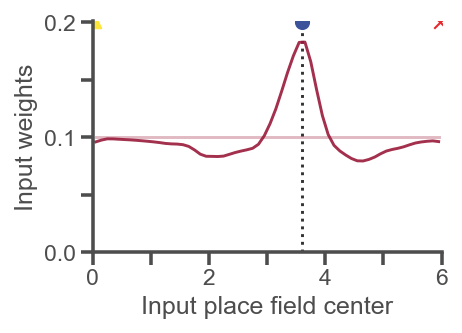

In [14]:
fig, sub_ax = plt.subplots(figsize=(3, 2))

plot_fcts.plot_recorded_1D_input_place_cell_weights(
    learner.get_recorded_weights()["weights"][:, 0],
    PCs.place_cell_centres,
    color=PCs.color,
    marker="none",
    lw=1.4,
    plot_last_FWHM=False,
    sub_ax=sub_ax,
)

format_PF_xaxis(sub_ax)
plot_util.expand_ticks(sub_ax, axis="y", num_ticks=5, alternating=True, round_dec=1)

for position in ["start", "reset", "target"]:
    Pyrs.Agent.add_positions_spatially_to_plot(
        sub_ax, position_name=position, y_1D=0.2, base_s=30
    )
target_pos = Pyrs.Agent.get_position("target", dim_idx=0)
sub_ax.set_xlabel("Input place field center")
sub_ax.axvline(target_pos, ls="dotted", color="k", alpha=0.8, zorder=-5, lw=1.4)

ALL_FIGURES["2B"] = sub_ax

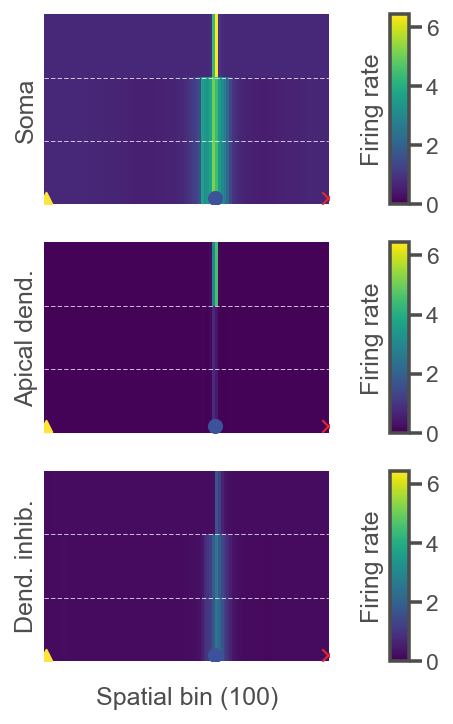

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(3.5, 5.6), squeeze=False)

kwargs = {
    "num_bins": 100,
    "vmin": 0,
    "cbar_aspect": 10,
    "plot_occ": False,
    "mark_runs": True,
    "shared_range": True
}

num_bins = 100
Pyrs.plot_binned_rates(axes=axes, **kwargs)
for sub_ax in axes.ravel():
    for position in ["start", "reset", "target"]:
        Pyrs.Agent.add_positions_spatially_to_plot(
            sub_ax, position_name=position, y_1D=2.4, pos_fact=100/6, pos_shift=-0.5, base_s=30
        )

labels = ["Soma", "Apical dend.", "Dend. inhib."]
for i, sub_ax in enumerate(axes.ravel()):
    sub_ax.set_title("")
    sub_ax.set_ylabel(labels[i])
sub_ax.set_xlabel(f"Spatial bin ({num_bins})", labelpad=12)

ALL_FIGURES["2C"] = axes

### Fig. 3: Speed and PF width
Takes about 2.5 min to rerun.

In [16]:
speed_data = run_fct("linear_speeds", overwrite=False)
regr = scipy.stats.linregress(speed_data["speed_means"], speed_data["PF_widths"])

Loading data from figures/paper/speed_data_18.npz.


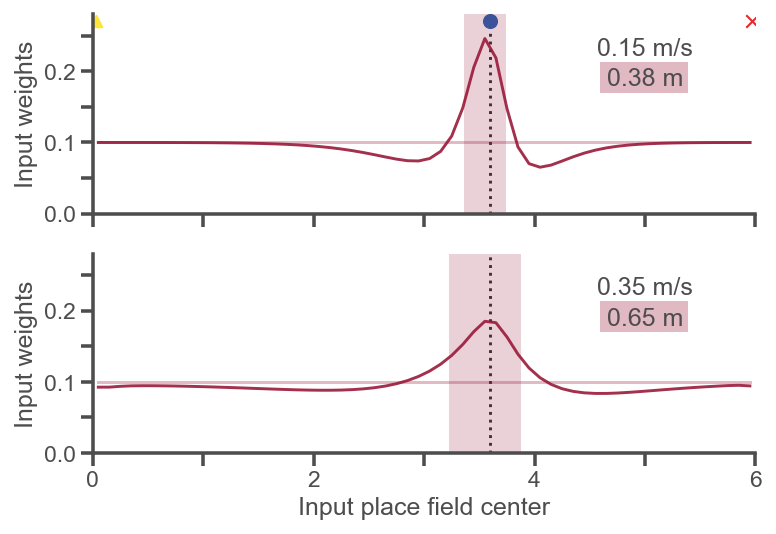

In [17]:
speeds_plot = [0.15, 0.35]
fig, ax1D = plt.subplots(len(speeds_plot), 1, figsize=(5.7, 3.8), sharex=True, sharey=True)
for i, speed_mean in enumerate(speeds_plot):
    sub_ax = ax1D[i]
    idx = np.where(speed_data["speed_means"] == speed_mean)[0][0]
    plot_fcts.plot_recorded_1D_input_place_cell_weights(
        speed_data["PF_weights"][idx],
        PCs.place_cell_centres,
        color=PCs.color,
        marker="none",
        plot_last_FWHM=True,
        lw=1.4,
        no_legend=True,
        sub_ax=sub_ax,
    )
    sub_ax.text(5, 0.223, f"{speeds_plot[i]} m/s", ha="center", fontsize=12)

    width = speed_data["PF_widths"][idx]
    width = np.around(width, 2)
    rect = mpl_patches.Rectangle((4.59, 0.17), 0.8, 0.043, color=PCs.color, alpha=0.3, lw=0)
    sub_ax.add_patch(rect)
    sub_ax.text(5, 0.18, f"{width} m", ha="center", fontsize=12)

for sub_ax in ax1D:
    sub_ax.set_ylim([0, 0.28])
    sub_ax.set_yticks([0, 0.25])
    plot_util.expand_ticks(sub_ax, axis="y", num_ticks=6, alternating=True, round_dec=2)
    target_pos = Pyrs.Agent.get_position("target", dim_idx=0)
    sub_ax.axvline(target_pos, ls="dotted", color="k", alpha=0.8, zorder=-5, lw=1.4)
    format_PF_xaxis(sub_ax)

ax1D[0].set_xlabel("")
ax1D[1].set_xlabel("Input place field center")
for position in ["start", "reset", "target"]:
    Pyrs.Agent.add_positions_spatially_to_plot(
        ax1D[0], position_name=position, y_1D=0.27, base_s=30
    )

ALL_FIGURES["3A"] = ax1D

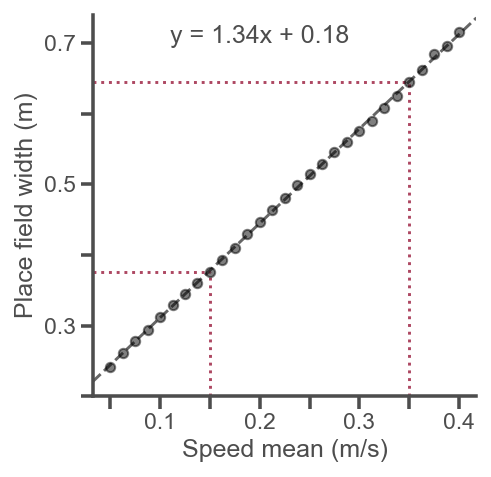

In [18]:
fig, sub_ax = plt.subplots(figsize=(3.3, 3.3))

sub_ax.scatter(speed_data["speed_means"], speed_data["PF_widths"], s=20, alpha=0.5, color="k")

# Format axes
for axis in ["x", "y"]:
    plot_util.pad_axis(sub_ax=sub_ax, axis=axis)
sub_ax.spines[["top", "right"]].set_visible(False)

sub_ax.set_xlabel("Speed mean (m/s)")
sub_ax.set_xticks([0.05, 0.4])
plot_util.expand_ticks(sub_ax, axis="x", num_ticks=8, alternating=True, round_dec=2, start_idx=1)

sub_ax.set_ylabel("Place field width (m)")
sub_ax.set_yticks([0.2, 0.7])
plot_util.expand_ticks(sub_ax, axis="y", num_ticks=6, alternating=True, round_dec=1, start_idx=1)

# Add regression
x = np.asarray(sub_ax.get_xlim())
y = x * regr.slope + regr.intercept
sub_ax.plot(x, y, alpha=0.6, color="k", ls="dashed", zorder=-5, lw=1.4)

regr_str = f"y = {regr.slope:.2f}x + {regr.intercept:.2f}"
sub_ax.text(0.11, 0.7, regr_str, fontsize=12)

xmin = sub_ax.get_xlim()[0]
ymin = sub_ax.get_ylim()[0]
for speed_mean in speeds_plot:
    idx = np.where(speed_data["speed_means"] == speed_mean)[0][0]
    width = speed_data["PF_widths"][idx]
    # sub_ax.arrow(speed_mean, width - 0.07, 0, 0.03, head_width=0.01, head_length=0.02, color=PCs.color)
    sub_ax.plot([speed_mean] * 2, [ymin, width], color=PCs.color, ls="dotted", zorder=-5, alpha=0.8, lw=1.4)
    sub_ax.plot([xmin, speed_mean], [width] * 2, color=PCs.color, ls="dotted", zorder=-5, alpha=0.8, lw=1.4)

ALL_FIGURES["3B"] = sub_ax

### Fig. 4: Effect of linear shifts
Takes about 5 min to rerun.

In [19]:
shift_data = run_fct("linear_shifts", overwrite=False)

Loading data from figures/paper/shift_data_18.npz.


In [ ]:
# shifts_plot = [-2, 0.3]
# fig, ax1D = plt.subplots(len(shifts_plot), 1, figsize=(5.7, 3.8), sharex=True, sharey=True)
# for i, target_shift in enumerate(shifts_plot):
#     sub_ax = ax1D[i]
#     idx = np.where(shift_data["target_shifts"] == speed_mean)[0][0]
#     plot_fcts.plot_recorded_1D_input_place_cell_weights(
#         speed_data["PF_weights"][idx],
#         PCs.place_cell_centres,
#         color=PCs.color,
#         marker="none",
#         plot_last_FWHM=True,
#         lw=1.4,
#         no_legend=True,
#         sub_ax=sub_ax,
#     )
#     sub_ax.text(5, 0.223, f"{speeds_plot[i]} m/s", ha="center", fontsize=12)

#     width = speed_data["PF_widths"][idx]
#     width = np.around(width, 2)
#     rect = mpl_patches.Rectangle((4.59, 0.17), 0.8, 0.043, color=PCs.color, alpha=0.3, lw=0)
#     sub_ax.add_patch(rect)
#     sub_ax.text(5, 0.18, f"{width} m", ha="center", fontsize=12)

# for sub_ax in ax1D:
#     sub_ax.set_ylim([0, 0.28])
#     sub_ax.set_yticks([0, 0.25])
#     plot_util.expand_ticks(sub_ax, axis="y", num_ticks=6, alternating=True, round_dec=2)
#     target_pos = Pyrs.Agent.get_position("target", dim_idx=0)
#     sub_ax.axvline(target_pos, ls="dotted", color="k", alpha=0.8, zorder=-5, lw=1.4)
#     format_PF_xaxis(sub_ax)

# ax1D[0].set_xlabel("")
# ax1D[1].set_xlabel("Input place field center")
# for position in ["start", "reset", "target"]:
#     Pyrs.Agent.add_positions_spatially_to_plot(
#         ax1D[0], position_name=position, y_1D=0.27, base_s=30
#     )

# ALL_FIGURES["4A"] = ax1D

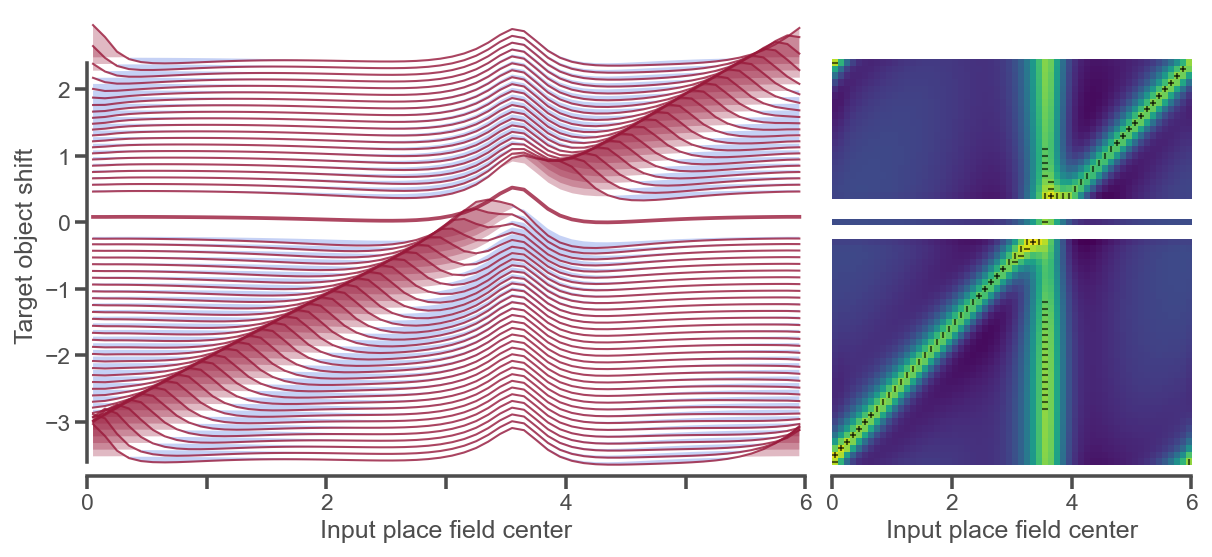

In [27]:
plot_relative = True

fig, ax1D = plt.subplots(1, 2, figsize=(9.5, 4), width_ratios=[2, 1], gridspec_kw={"wspace": 0.05}, sharey=True)
for sub_ax in ax1D:
    sub_ax.spines[["top", "right"]].set_visible(False)

base_shift = np.nanmin(shift_data["PF_weights"][0][1])
plot_weights(PCs, shift_data["PF_weights"][0][1] - base_shift, lw=1.8, sub_ax=ax1D[0])

relative = shift_data["PF_weights"][0][1] - base_shift if plot_relative else None
for i, shift in enumerate(shift_data["target_shifts"]):
    last = shift_data["PF_weights"][i, -1]
    if np.isfinite(last.all()):
        plot_weights(PCs, last - base_shift, shift=shift, relative=relative, lw=1.0, sub_ax=ax1D[0])

format_PF_xaxis(ax1D[0])

ax1D[0].set_xlabel("Input place field center")
ax1D[0].set_ylabel("Target object shift")
ymin = shift_data["target_shifts"].min()
ymax = shift_data["target_shifts"].max()
yticks = [y for y in ax1D[0].get_yticks() if y >= ymin and y <= ymax]
ax1D[0].spines["left"].set_bounds(ymin, ymax)
ax1D[0].set_yticks(yticks)

num_shifts = len(shift_data["PF_weights"])
data = np.full((num_shifts, PCs.n), np.nan)
for i, shift in enumerate(shift_data["target_shifts"]):
    idx = 1 if shift == 0 else -1
    data[i] = shift_data["PF_weights"][i][idx]
    
argmax_each = np.argmax(data, axis=-1)
PC_centre_max = PCs.place_cell_centres[argmax_each]
PC_centre_max[np.isnan(data).all(axis=-1)] = np.nan
argmax_across = np.nanargmax(data, axis=0)

sep_x = np.diff(PCs.place_cell_centres.ravel()).mean()
extent_x = [PCs.place_cell_centres.min() - sep_x / 2, PCs.place_cell_centres.max() + sep_x / 2]
sep_y = np.diff(shift_data["target_shifts"]).mean()
extent_y = [shift_data["target_shifts"].min() - sep_y / 2, shift_data["target_shifts"].max() + sep_y / 2]

x_corr = 1.0022
ax1D[1].imshow(data[::-1], interpolation="none", aspect="auto", cmap="viridis", extent=[*extent_x, *extent_y])
ax1D[1].scatter(PC_centre_max * x_corr, shift_data["target_shifts"], color="k", s=8, marker="_", alpha=0.6)
ax1D[1].scatter(PCs.place_cell_centres.ravel() * x_corr, shift_data["target_shifts"][argmax_across], color="k", s=8, marker="|", alpha=0.6)
ax1D[1].set_xlabel(f"Input place field center")
ax1D[1].spines["left"].set_visible(False)
ax1D[1].tick_params(axis="y", length=0)

plot_util.pad_axis(ax1D[0], axis="y", pad_prop=0.05)

ALL_FIGURES["4B"] = ax1D

### Fig. 5: 2D environment and teleportation

In [21]:
RECORD_WEIGHTS_FREQ = 1000
MAX_NUM_STEPS = 15000

locations = {
    "start": [0.2, 0.8],
    "reward": [0.25, 0.1],
    "teleport_in_out": [[0.6, 0.5], [0.2, 0.1]],
    "wall_coords": [[0, 0.2], [0.6, 0.2]],
}
locations = {key: np.asarray(data) * params_util.SCALE for key, data in locations.items()}

env_params = params_util.get_env_params(
    environment="openfield",
    init_random_reward_obj=0,
    init_random_novel_obj=0,
    init_random_walls=0,
    init_random_teleport_pairs=0,
    walls=copy.deepcopy([locations["wall_coords"]]),
    init_reward_obj=copy.deepcopy([locations["reward"]]),
    init_teleport_pairs=copy.deepcopy([locations["teleport_in_out"]]),
)

agent_params = params_util.get_agent_params(
    environment="openfield",
    reward_factor=5,
    no_target_factor=1,
)

Obj_params = params_util.get_Obj_params(
    environment="openfield",
    num_novel=0,
    num_teleport=0,
    num_reward=1,
    )

PC_params = params_util.get_PC_params(
    environment="openfield",
)

VN_params = {
    "n": 1,
    "peak": copy.deepcopy(locations["reward"]),
    "description": "gaussian",
    "max_fr": 10,
    "widths": 0.6,
}

Pyr_params = params_util.get_Pyr_params(
    n=1, 
    environment="openfield",
    log_BTSP=True,
)

### Fig. 6: Multiple targets

### Save figures

In [22]:
SAVE = True

In [28]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)

Saving 8 figures...
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/1B_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/1D_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/2A_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/2B_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/2C_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/3A_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/3B_1605.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_17/4B_1605.png  & .svg
